# Importing Needed Libraries 

In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# Read Dataset

<AxesSubplot:xlabel='X', ylabel='Y'>

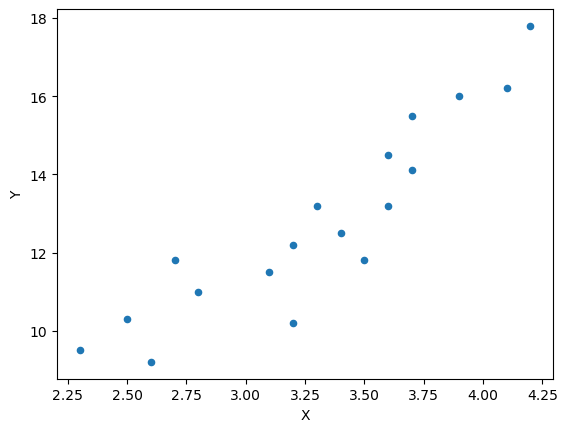

In [26]:
df = pd.read_excel("./Dataset/IDS_13-Dataset.xlsx")

df.plot.scatter(x="X", y="Y")

In [20]:
## Dataset Setup

X = df[["X"]]
Y = df["Y"]

In [56]:
## Create Model

model = LinearRegression()
model.fit(X, Y)

LinearRegression()

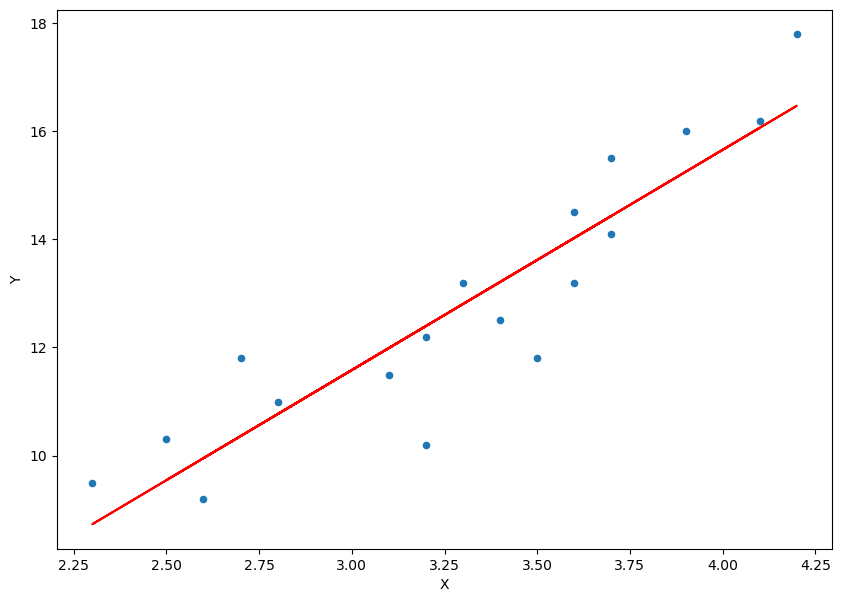

In [57]:
## Visualization

df.plot.scatter(x="X", y="Y", figsize=(10,7))
Y_predict = model.predict(X)
plt.plot(X, Y_predict, color="red")

In [58]:
## Evaluate
#y = b0 + b1 x
#b0 = intercept
#b1 = coef

print("Intercept: ", model.intercept_)
print("Coefficent: ", model.coef_)

# Biasanya Dataset dibisahkan antara dataset training dan testing
print("R^2: ", model.score(X, Y))


Intercept:  -0.6502583979328183
Coefficent:  [4.07751938]
R^2:  0.8310710981120178


In [59]:
## Predicting based on inputed X value

pred_2 = model.predict([[2]])
pred_5 = model.predict([[5]])

/home/wilbert/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/wilbert/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [60]:
print(pred_2)
print(pred_5)

[7.50478036]
[19.7373385]


In [61]:
# Autos Prediction

df_autos = pd.read_csv("./Dataset/autos.csv")

df_autos

,make,fuel.type,aspiration,num.doors,body.style,drive.wheels,engine.location,wheel.base,length,width,...,engine.size,fuel.system,bore,stroke,compression.ratio,horsepower,peak.rpm,city.mpg,highway.mpg,price
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
189,volvo,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
190,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
191,volvo,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


<AxesSubplot:>

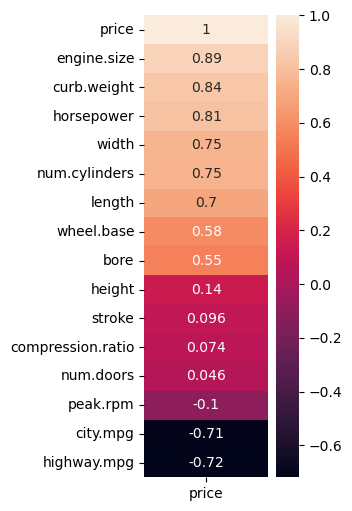

In [63]:
# Exploration

plt.figure(figsize=(2,6))
sns.heatmap(df_autos.corr()[['price']].sort_values(by='price', ascending=False), annot=True)

Intercept:  -8862.787970732035
Coefficent:  [172.86186017]
R^2:  0.7899272137265414


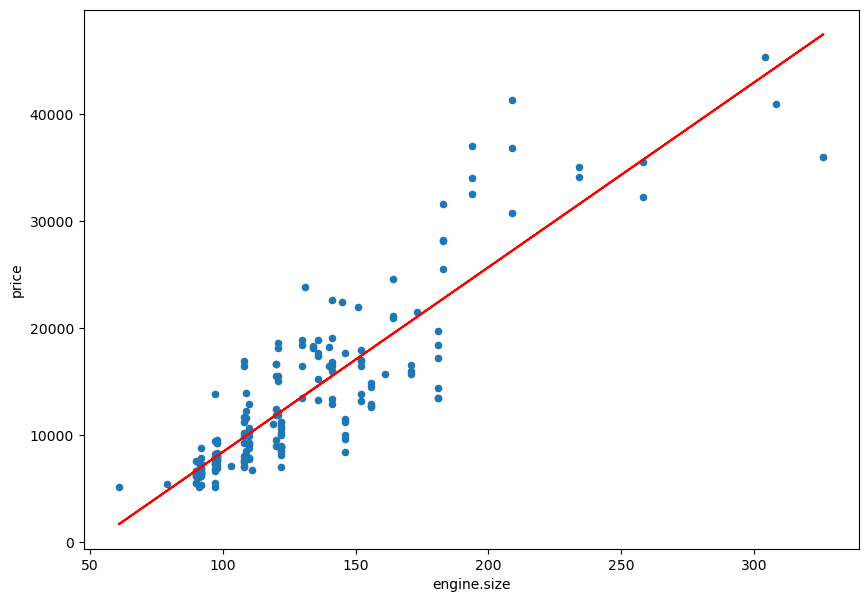

In [71]:
## Dataset Setup

factor = "engine.size"

X = df_autos[[factor]]
Y = df_autos["price"]

## Create Model

model = LinearRegression()
model.fit(X, Y)

df_autos.plot.scatter(x=factor, y="price", figsize=(10,7))
Y_predict = model.predict(X)
plt.plot(X, Y_predict, color="red")

## Evaluate
#y = b0 + b1 x
#b0 = intercept
#b1 = coef

print("Intercept: ", model.intercept_)
print("Coefficent: ", model.coef_)

# Biasanya Dataset dibisahkan antara dataset training dan testing
print("R^2: ", model.score(X, Y))

In [78]:
df_autos.corr().columns

Index(['num.doors', 'wheel.base', 'length', 'width', 'height', 'curb.weight',
       'num.cylinders', 'engine.size', 'bore', 'stroke', 'compression.ratio',
       'horsepower', 'peak.rpm', 'city.mpg', 'highway.mpg', 'price'],
      dtype='object')

In [85]:
# Multinomial
## Dataset Setup

X = df_autos[['num.doors', 'wheel.base', 'length', 'width', 'height', 'curb.weight',
       'num.cylinders', 'engine.size', 'bore', 'stroke', 'compression.ratio',
       'horsepower', 'peak.rpm', 'city.mpg', 'highway.mpg']]
Y = df_autos["price"]

## Create Model

model = LinearRegression()
model.fit(X, Y)

## Evaluate
#y = b0 + b1 x
#b0 = intercept
#b1 = coef

print("Intercept: ", model.intercept_)
print("Coefficent: ", model.coef_)

# Biasanya Dataset dibisahkan antara dataset training dan testing
print("R^2: ", model.score(X, Y))

Intercept:  -50966.411736602066
Coefficent:  [ 7.96641950e+01  4.48340775e+01 -8.92116486e+01  6.90939967e+02
  3.38392396e+02  8.82110976e-01 -1.48792462e+03  1.73240273e+02
 -3.43045966e+03 -4.18208659e+03  2.68763242e+02  4.23631308e+01
  2.12695918e+00 -2.60624611e+02  2.31756515e+02]
R^2:  0.8600770852537737
